In [1]:
import os
import time
import math
import nltk
import datetime
import ast
import pandas as pd
import numpy as np
import networkx as nx
from atproto import Client
from matplotlib import pyplot as plt
from dotenv import load_dotenv
from nltk.sentiment.vader import SentimentIntensityAnalyzer

To combine both of the major concepts that are covered in the course this project intends to use the sentiment of individual users on social media with the network that they exist in to see if there is a connection with the sentiment a user uses and the people they are connected to. To do this we need to access a social media site with public facing posts and following information. As previously discussed in the semester a number of major social media platforms have pushed to remove or restrict access to their data. When this project was concieved the goal was to use Twitter's data because it's small post limits, large and diverse user base were ideal for this kind of analysis. But in February of 2023 Twitter removed access to it's free API. Bluesky, originally an offshoot of Twitter, has a very similar model to post limitations and the niche it is trying to fill is almost identical to Twitter but with one key difference, a focus on user agency and less reliance on behind the scenes control over what users see and interact with. This means that it has left access to it's API free and accessible to anyone who has a Bluesky account. We can use this platform to perform this same analysis with just a few drawbacks to this minor change. Bluesky has a smaller userbase since it is much newer and it's audience is much less diverse. Fortunately since this project's scope is limited to a very small subset of the platform we can just assume these understandings into our results. We are going to be looking some of the highest followed accounts on the platform as these will represent the most "famous" people and will give a decent analysis of what most users will see as a majority of users will be connected to this network by at least one of these users.

To start we just need to initiate our connection to the Bluesky API using our username and password. After initiating the client we can use this client for all of our API calls, we can access almost anything posted to the site with a simple call as shown below.

In [2]:
load_dotenv()
username = os.getenv('login')
password = os.getenv('password')

client = Client()
client.login(username, password)

profile = client.app.bsky.feed.get_author_feed({'actor': 'hankgreen.bsky.social', 'limit': 5})

for ea in profile.feed:
    post = ea.post
    print(post.record.text)

Join John and I for a discussion of Partner's in Health's work in Sierra Leone! events.zoom.us/egj/AmAzdFQG...
Hot Take: Clavicular (as influencer) doesn't exist. 

He is far more popular with people who hate him than people who like him. He's a perfect package of trainwreck, ideologically repulsive, fascinating, threatening, and confusing. He's a hypersalience smoothie but his actual audience is tiny.
Where am I supposed to use this?
By far the most annoying stranger interaction you get as a semi-famous person is the stranger who hears that you’re semi-famous and then needs you to justify your fame to them. 

Like, I dunno, buddy, I’m good at making youtube videos. Do you want a selfie or can I get back to my friends?
🙂‍↕️


The initial thought for this project was to get a sample of the userbase around the largest profiles on the platform. Unfortunately the Bluesky API doesn't have much in the way of filtered queries. Most queries can just return what they call in pagiated data, this means that any true random sampling would have to be done after the fact. The idea was to start with a high profile account and go through and select users that have a decent number of followers (thousands) and at least 100 posts that can be used for sentiment analysis. Then go through and get the users that follow all of those users and so on until most of the site had be scraped. Unfortunately we do not have the resourcing nor the time to effectively do this for the high reach connective users that were intended for this project. Below is the code that was originally going to be used but then the resourcing was not available, I would normally delete this out of the project but I had fun writing a recursive function to get all members of a network so I would just like to have it acknowledge despite it not making it into the final process.

In [54]:
# def profile_info(profile):
#     print('Handle:        ', profile.handle)
#     print('Display Name:  ', profile.display_name)
#     print('Posts Count:   ', profile.posts_count)
#     print('Followers:     ', profile.followers_count)
#     print('Following:     ', profile.follows_count)

# def follower_network(user, relationships, checked, num):
#     cursor = None
#     more = True
#     go = len(relationships) < num
#     profile = client.app.bsky.actor.get_profile({'actor': user})
#     profile_info(profile)
#     i = 0
    
#     while more:
#         i = i + 1
#         if i % 10 == 0:
            # print(i * 100, 'users checked.', 
            #       len(relationships), 'connections saved')
#         params = {'actor': user, 'limit': 100}
#         params['cursor'] = cursor
#         try:
#             followers = client.app.bsky.graph.get_followers(params)
            
#             for f in followers.followers:
#                 try:
#                     p = client.app.bsky.actor.get_profile({'actor': f.handle})
                    # if np.logical_and(p.posts_count > 100, 
                    #                   p.followers_count > num):
#                         relationships.append((user, p.handle))
#                 except Exception as e:
#                     print('Skipping user:', f.handle, 'because', e)
#         except Exception as e:
#             print('Skipping user:', user, 'because', e)
#             more = False

#         cursor = followers.cursor
#         if cursor == None:    
#             more = False
#         time.sleep(1)

#     checked.append(user)
    
#     for ea in relationships:
#         if not (ea[1] in checked):
            # relationships = relationships + follower_network(
                # ea[1], relationships, checked, num)    
    
#     return relationships

# relationships = []
# checked = []

# hank = 'hankgreen.bsky.social'
# net = follower_network(hank, relationships, checked, 90000)

# print(net)

To pivot to a more sustainable method a list of the top most followed accounts on the platform was use from [vqv.app](https://vqv.app/). This uses the API to maintain a list of the top 1000 most followed accounts on Bluesky. This was then used to build the network so scraping all of the followers of a user wouldn't be required. It is assumed that there is going to be a bit of a skew in the data since this is only top users, this means that the sentiment will only be representative of these users (like asking the political opinions of the top 1000 earners in a country, while the data means something it is not necessarily representative of the whole population). Again this is acceptable as most users are likely to be connected to this network in some way or the other since these are the top followed users on the whole platform. The data had to be directly copy paste from the webpage requiring these extra data processing steps.

In [4]:
df = pd.read_csv('top1000.txt', sep='\t', names = ['raw'])
df1 = df[df['raw'].str.startswith('@')]
df2 = df1.reset_index(drop=True).rename(columns = {'raw': 'users'})
top = df2['users'].str.slice(1)

top.head(5)

0                   aoc.bsky.social
1                mcuban.bsky.social
2    markhamillofficial.bsky.social
3                      theonion.com
4                       nytimes.com
Name: users, dtype: object

Each profile on Bluesky has a unique DID (Decentralized Identifier) this is a non-user facing value that is basically used to identify a user profile even if they change everything about the account. This value never changes and will be used by certain API calls so having a reference for each user handle is helpful to maintain efficiency (instead of calling for the DID whenever it is necessary this onetime call in batches allows the number of calls to be minimized since there is a limit to the number of calls a user can make within a certain time period.)

In [5]:
dids = []
groups = [list(top)[i:i+25] for i in range(0, len(top), 25)]
for ea in groups:
    try:
        profiles = client.app.bsky.actor.get_profiles({"actors": ea})
        for profile in profiles.profiles:
            dids.append((profile.handle, profile.did))
    except Exception as e:
        print(e)

As stated for getting the DIDs there are batch calls in the Bluesky API which allow for minimizing the number of calls which helps to not overload the servers and increase efficiency. This function will take two variables, a single user and then a list of users (30 per batch limit per API call function). Then the function will get the relationships between all of the users in the group in relation to the primary user passed through. This will then return the relationship between them, a 0 if the user in the group is followed by the primary user, a 1 if the primary user is followed by the user in the group, and a 2 if they both follow each other. This can later be decoded for a directional graph.

In [6]:
def get_relationships(user1, group):
    groupdid = []
    r = []
    for ea in group:
        groupdid.append(ea[1])
    
    relations = client.app.bsky.graph.get_relationships({'actor': user1[1],'others': groupdid})
    for ea, i in zip(relations.relationships, range(len(relations.relationships))):
        if np.logical_and(ea.following != None, ea.followed_by != None):
            # print(user1[0], 'and', group[i][0], 'follow each other')
            r.append((user1, group[i], 2))
        elif np.logical_and(ea.following != None, ea.followed_by == None):
            # print(user1[0], "follows", group[i][0])
            r.append((user1, group[i], 1))
        elif np.logical_and(ea.following == None, ea.followed_by != None):
            # print(user1[0], "is followed by", group[i][0])
            r.append((user1, group[i], 0))
    #returns 0 if first is followed by second, 1 if first is following the second, 2 if both follow each other
    return r 

The batches are created by iterating through the list of all the users collected. This is done by starting at the top of the list and requesting the relationships to all other users in the list in batches of 30. Then once the relationships for that user have been determined that user can be excluded on the basis that they have been checked against every user already. Then we can continue onward until we have gone through every user in the list.

In [7]:
# ==========================================================================
# Option 1: For when you don't have any existing values
# ==========================================================================
# all_relationships = []
# remain_dids = dids.copy()

# print(datetime.datetime.now(), '0 /', len(remain_dids), 'users processed')
# for i in range(len(remain_dids)):
#     for ea in [remain_dids[j:j+30] for j in range(i+1, len(remain_dids), 30)]:
        # all_relationships = all_relationships + get_relationships(
        #     remain_dids[i], ea)
#         time.sleep(1)    
#     pd.DataFrame(all_relationships).to_csv('relationships.csv', index = False)
#     if (i+1) % 20 == 0:
        # print(datetime.datetime.now(), (i+1), '/', 
        #       len(remain_dids), 'users processed')

# pd.DataFrame(all_relationships).to_csv(
    # 'relationships' + str(round(time.time())) + '.csv', index = False)

# ==========================================================================
# Option 2: For when you have already processed some data and saved it
# ==========================================================================
# all_relationships = pd.read_csv('relationships.csv')

# all_relationships['0'] = all_relationships['0'].apply(ast.literal_eval)
# all_relationships['1'] = all_relationships['1'].apply(ast.literal_eval)
# remain_dids = list(set(dids) - set(all_relationships['0']))
# all_relationships = all_relationships[['0','1','2']].values.tolist()

# print(datetime.datetime.now(), '0 /', len(remain_dids), 'users processed')
# for i in range(len(remain_dids)):
#     for ea in [remain_dids[j:j+30] for j in range(i+1, len(remain_dids), 30)]:
        # all_relationships = all_relationships + get_relationships(
        #     remain_dids[i], ea)
#         time.sleep(1)    
#     pd.DataFrame(all_relationships).to_csv('relationships.csv', index = False)
#     if (i+1) % 10 == 0:
        # print(datetime.datetime.now(), (i+1), '/', 
        #       len(remain_dids), 'users processed')

# pd.DataFrame(all_relationships).to_csv(
#     'relationships' + str(round(time.time())) + '.csv', index = False)

# ==========================================================================
# Option 3: For when you have all the data processed and saved it
# ==========================================================================
all_relationships = pd.read_csv('relationships.csv')
all_relationships['0'] = all_relationships['0'].apply(ast.literal_eval)
all_relationships['1'] = all_relationships['1'].apply(ast.literal_eval)

In [8]:
all_relationships.head(5)

,0,1,2
0,"(aoc.bsky.social, did:plc:p7gxyfr5vii5ntpwo7f6...","(mcuban.bsky.social, did:plc:y5xyloyy7s4a2bwfe...",2
1,"(aoc.bsky.social, did:plc:p7gxyfr5vii5ntpwo7f6...","(markhamillofficial.bsky.social, did:plc:xyddp...",0
2,"(aoc.bsky.social, did:plc:p7gxyfr5vii5ntpwo7f6...","(theonion.com, did:plc:a4pqq234yw7fqbddawjo7y35)",1
3,"(aoc.bsky.social, did:plc:p7gxyfr5vii5ntpwo7f6...","(nytimes.com, did:plc:eclio37ymobqex2ncko63h4r)",1
4,"(aoc.bsky.social, did:plc:p7gxyfr5vii5ntpwo7f6...","(georgetakei.bsky.social, did:plc:y4zs4cabaezz...",2
...,...,...,...
155972,"(mjsdc.bsky.social, did:plc:6h7b2i6ttw3l4t7pvb...","(rtraister.bsky.social, did:plc:rh3rd65obpbgpj...",2
155973,"(scottcrates.bsky.social, did:plc:wxnw7sehp2fh...","(letatcestmoi.bsky.social, did:plc:6x746rseeck...",2
155974,"(letatcestmoi.bsky.social, did:plc:6x746rseeck...","(annecaprara.bsky.social, did:plc:lihw4huhnze7...",1
155975,"(letatcestmoi.bsky.social, did:plc:6x746rseeck...","(rtraister.bsky.social, did:plc:rh3rd65obpbgpj...",1


We can then take the values and make an edge list based on what the relationship between the two users is. If they follow each other we make two connections, one in both directions, to ensure directionality can be used later.

In [9]:
edges = []

for ea in all_relationships[['0','1','2']].values.tolist():
    if ea[2] == 2:
        edges.append((ea[0][0], ea[1][0]))
        edges.append((ea[1][0], ea[0][0]))
    elif ea[2] == 1:
        edges.append((ea[0][0], ea[1][0]))
    if ea[2] == 0:
        edges.append((ea[1][0], ea[0][0]))

This next function receives a user profile and then goes into their feed and takes the top 100 posts to calculate a sentiment score for the user. It gets the sentiment score for each individual post and also concatenation of all of the posts into a single body. It then calculates averages, minimums and maximums and returns those along with the sentiment score for the concatenated posts.

In [10]:
def get_sentiment(user):
    feed = client.app.bsky.feed.get_author_feed({'actor': user[0], 'limit':100})
    score100 = []
    all100 = ''
    for post in feed.feed:
        text = post.post.record.text
        score = SentimentIntensityAnalyzer().polarity_scores(text)['compound']
        all100 = all100 + text
        score100.append(score)
    if len(score100) == 0:
        return (user[0], user[1], 0, 0, 0, 0, 0)
    score_all = SentimentIntensityAnalyzer().polarity_scores(all100)['compound']
    
    return (user[0], user[1], np.mean(score100), 
            np.median(score100), np.min(score100), np.max(score100), score_all)

To run through the users we iterate through the list of DIDs and append the results to a list that gets saved to be more efficiently accessed later. We can then put these values into a `pandas` dataframe for ease of data manipulation and analysis.

In [12]:
# sentiments = []
# for ea in dids:
#     sentiments.append(get_sentiment(ea))
#     if len(sentiments) % 20 == 0:
        # print(datetime.datetime.now(), len(sentiments),
        #       '/', len(dids), 'processed')
#     time.sleep(1)

# df_sentiments = pd.DataFrame(sentiments, 
#                         columns = ['handle', 'did', 'mean', 'median', 
#                             'min', 'max', 'total'])
# df_sentiments.to_csv('sentimentscores.csv')

# sent = sentiments.copy()
# sent1 = pd.DataFrame(sent, 
#                      columns = ['handle', 'did', 
#                           'mean', 'median', 'min', 'max', 'total'])
# sent1.head(5)

# ==========================================================================
# Alternate Option: If you have the sentiment scores processed and saved
# ==========================================================================
sent = pd.read_csv('sentimentscores.csv')
sent1 = pd.DataFrame(sent, 
                     columns = ['handle', 'did', 'mean', 
                                'median', 'min', 'max', 'total'])
sent1.head(5)

,handle,did,mean,median,min,max,total
0,aoc.bsky.social,did:plc:p7gxyfr5vii5ntpwo7f6dhe2,-0.003449,0.03860,-0.9246,0.9429,-0.9982
1,mcuban.bsky.social,did:plc:y5xyloyy7s4a2bwfeimj7r3b,0.085550,0.00000,-0.9366,0.9100,0.9977
2,markhamillofficial.bsky.social,did:plc:xyddpg6usmgh2t2jgf4e37yk,0.038795,0.00000,-0.8866,0.9180,0.9688
3,theonion.com,did:plc:a4pqq234yw7fqbddawjo7y35,0.010351,0.00000,-0.9673,0.8526,-0.2682
4,nytimes.com,did:plc:eclio37ymobqex2ncko63h4r,-0.103323,-0.07715,-0.9022,0.9409,-0.9990


We can see below the histogram of the sentiment scores different distributions. We can see that the mean has the most normal distribution and the most spread to the data. This will allow us to have a decent number of positive, negative, and neutral users per category and will lead to a more impactful analysis. The use of median isn't that helpful here because it is resilient to outliers, typically this is a plus but in this case that means that we have a lot of users drifting to the center of the sentiment scores. Over 80% score around a 0. This makes sense as most users will have a mix of positive and negative posts which will average out to a median score of 0 overall, but with the mean extreme scores will pull the average closer to one side which is a better representation of a user. As an example lets say User A has three posts "Good job", "Okay job", "Bad job" and User B has three similar posts "Fantastic awesome amazing job!!!", "alright job", "wasn't terrible job". While the median score here for both User A and B would be neutral, we can clearly see a meean sentiment value for User B would be pulled in the positive direction by their high positive score on the first post and low negative score on the third. This is the same concept for all 100 posts but on a larger scale. This leads to the decision of using the mean sentiment values to calculate whether a user has positive, negative or neutral sentiment.

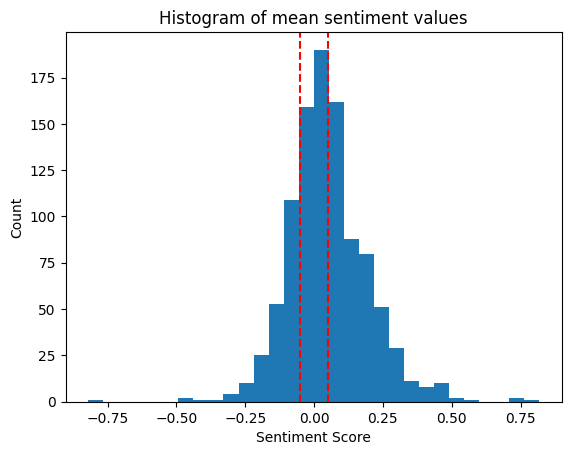

In [40]:
plt.hist(sent1['mean'], bins = 30)
plt.axvline(x=0.05, color='r', linestyle='--')
plt.axvline(x=-0.05, color='r', linestyle='--')
plt.title('Histogram of mean sentiment values')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

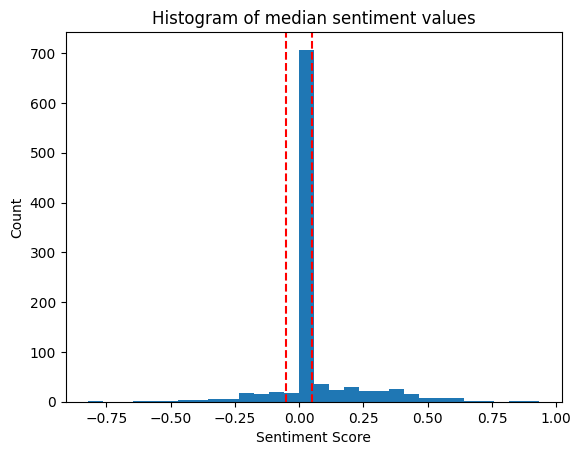

In [43]:
plt.hist(sent1['median'], bins = 30)
plt.axvline(x=0.05, color='r', linestyle='--')
plt.axvline(x=-0.05, color='r', linestyle='--')
plt.title('Histogram of median sentiment values')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

Interestingly there are some users whose 100 most recent posts have no negativity in them but the vast majority have at least one that is extremely (almost entirely) negative.

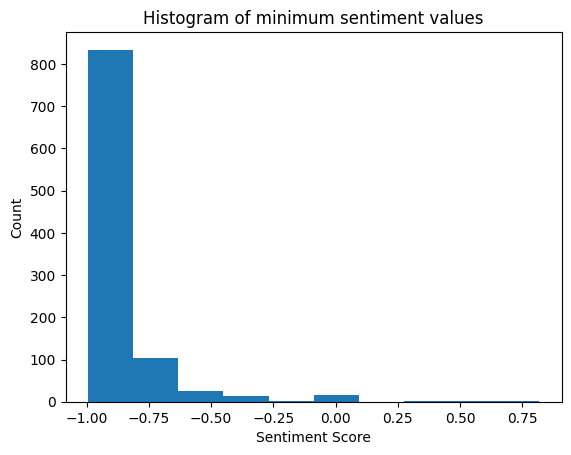

In [15]:
plt.hist(sent1['min'])
plt.title('Histogram of minimum sentiment values')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

Contrary to many conceptions about the social internet there are most users who are not all negative than those that are all positive. This can be seen by comparing the number of outliers on the minimum sentiment values graph to the maximum sentiment values graph.

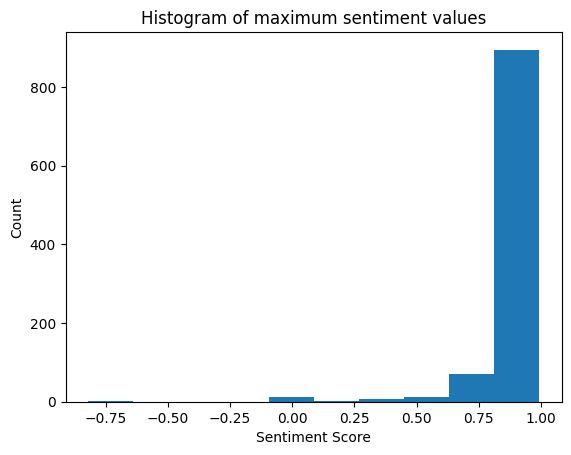

In [16]:
plt.hist(sent1['max'])
plt.title('Histogram of maximum sentiment values')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

This graph is extremely interesting and I cannot understand why the values look like this. For some reason taking all the posts and putting them into a single body of text polarizes the scores like this. While this is interesting and probably would make for a great graph to get likes on social media, I believe it is an artifact of how the sentiment score get calculated and should be ignored since it is not fully understood.

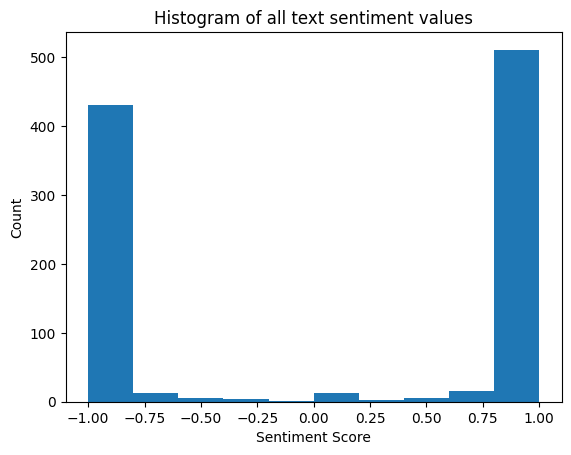

In [17]:
plt.hist(sent1['total'])
plt.title('Histogram of all text sentiment values')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

Since we determined that using the mean values to determine sentiment is the best course forward we can assign a sentiment value based on the cutoff of $\pm$ 0.05, which is what the Vader sentiment library recommends for these scores. Now each user will be categorized as having a positive, negative or neutral sentiment.

In [18]:
df_sent = sent1.loc[:,['handle', 'did', 'mean']]
df_sent['sentiment'] = df_sent['mean'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))
df_sent.head(5)

,handle,did,mean,sentiment
0,aoc.bsky.social,did:plc:p7gxyfr5vii5ntpwo7f6dhe2,-0.003449,Neutral
1,mcuban.bsky.social,did:plc:y5xyloyy7s4a2bwfeimj7r3b,0.085550,Positive
2,markhamillofficial.bsky.social,did:plc:xyddpg6usmgh2t2jgf4e37yk,0.038795,Neutral
3,theonion.com,did:plc:a4pqq234yw7fqbddawjo7y35,0.010351,Neutral
4,nytimes.com,did:plc:eclio37ymobqex2ncko63h4r,-0.103323,Negative


Again we can see here that almost half of users have a positive sentiment which goes against the concept that the social internet is a negative hateful place. I think negativity tends to stick out in our minds so we tend to remember the negative stronger than the positive.

In [19]:
df_sent['sentiment'].value_counts()

sentiment
Positive    449
Neutral     328
Negative    223
Name: count, dtype: int64

Then it came time to actually build the network. We continued `networkx` as this is what we have used for most of the semester. We start with a blank directed graph and then add the edges we created earlier. We can then calculate our centrality measures and add them to our dataframe with our sentiment scores.

In [20]:
G = nx.DiGraph()
G.add_edges_from(edges)

dc = nx.degree_centrality(G)
bc = nx.betweenness_centrality(G)
ec = nx.eigenvector_centrality(G)
cc = nx.closeness_centrality(G)

df_sent['degree'] = df_sent['handle'].map(dc)
df_sent['betweenness'] = df_sent['handle'].map(bc)
df_sent['eigenvector'] = df_sent['handle'].map(ec)
df_sent['closeness'] = df_sent['handle'].map(cc)
df_sent.head(5)

,handle,did,mean,sentiment,degree,betweenness,eigenvector,closeness
0,aoc.bsky.social,did:plc:p7gxyfr5vii5ntpwo7f6dhe2,-0.003449,Neutral,0.869870,0.010736,0.083563,0.699543
1,mcuban.bsky.social,did:plc:y5xyloyy7s4a2bwfeimj7r3b,0.085550,Positive,0.629630,0.004013,0.064891,0.604064
2,markhamillofficial.bsky.social,did:plc:xyddpg6usmgh2t2jgf4e37yk,0.038795,Neutral,1.006006,0.021230,0.064724,0.612891
3,theonion.com,did:plc:a4pqq234yw7fqbddawjo7y35,0.010351,Neutral,0.441441,0.000000,0.057213,0.589582
4,nytimes.com,did:plc:eclio37ymobqex2ncko63h4r,-0.103323,Negative,0.426426,0.001343,0.055644,0.585978


We can also add these to be attributes of each node in the network, this doesn't help in our analysis but allows for interconnectedness of the data.

In [21]:
sent_dict = df_sent.set_index('handle').to_dict(orient = 'index')
nx.set_node_attributes(G, sent_dict)

Then we can assign a color map based on the sentiment scores to help visualize the scores in the network once the network has been graphed.

In [22]:
color_map = []
for user, attr in G.nodes(data=True):
    if attr.get('sentiment') == 'Positive':
        color_map.append('blue')
    elif attr.get('sentiment') == 'Negative':
        color_map.append('red')
    else:
        color_map.append('gray')

Unfortunately, as is normally the case with such large networks, there isn't much meaningful to be glean from the visualization of this network. Even after tryinging multiple layouts and different setttings it is very difficult to glean anything from such a large network. For interpretable visualizations of networks it would be highly recommended to load the data into a dynamic visualizer that can have values tweaked to more easily manipulate the network.

In [23]:
pos_spiral = nx.spiral_layout(G)
pos_arf = nx.arf_layout(G)
pos_kk = nx.kamada_kawai_layout(G)

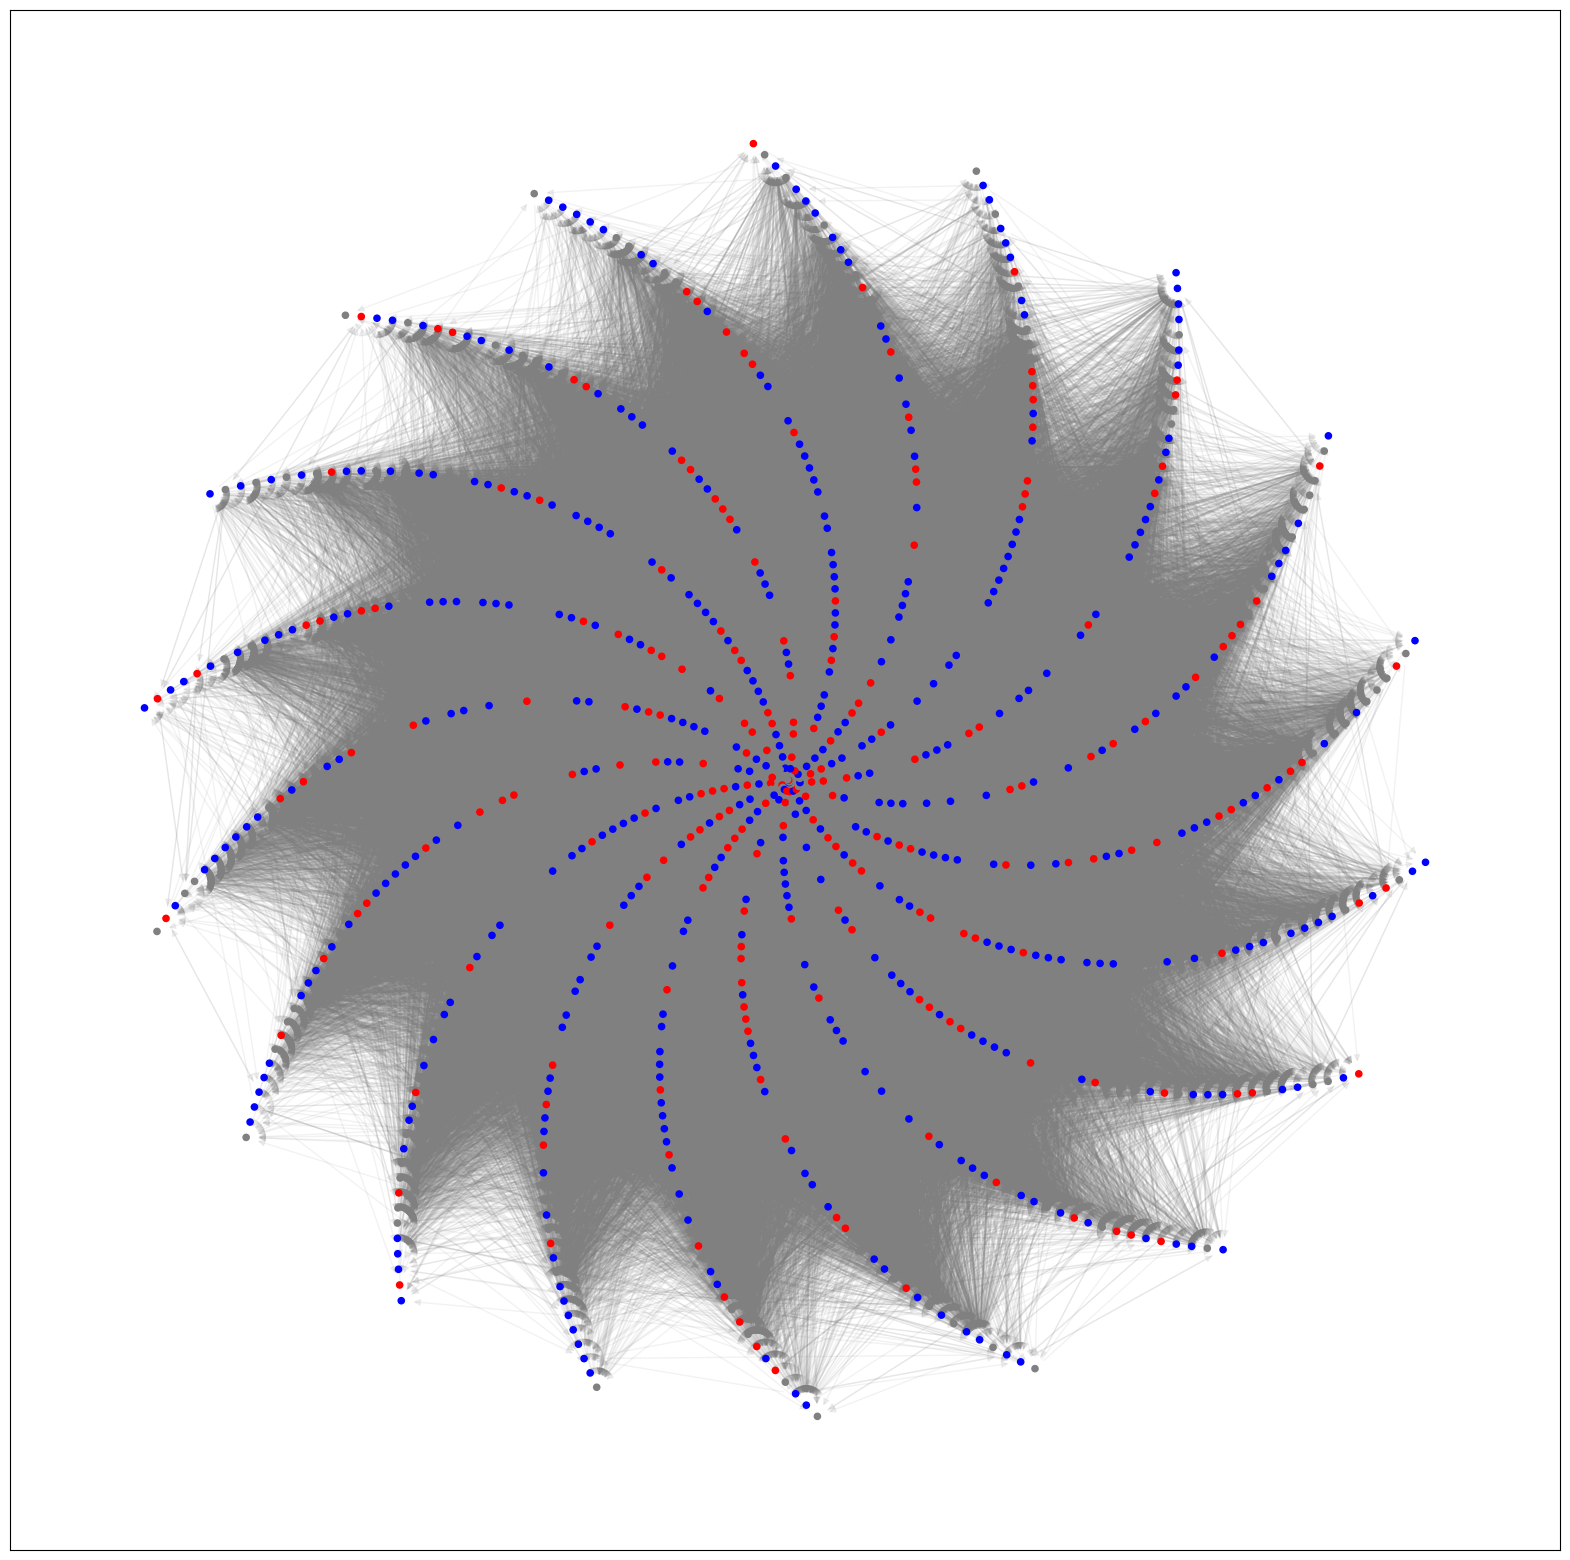

In [24]:
plt.figure(figsize=(20, 20)) 
nx.draw_networkx_edges(G, pos_spiral, edge_color='gray', alpha = 0.1)
nx.draw_networkx_nodes(G, pos_spiral, node_color=color_map, node_size=20)
plt.show()

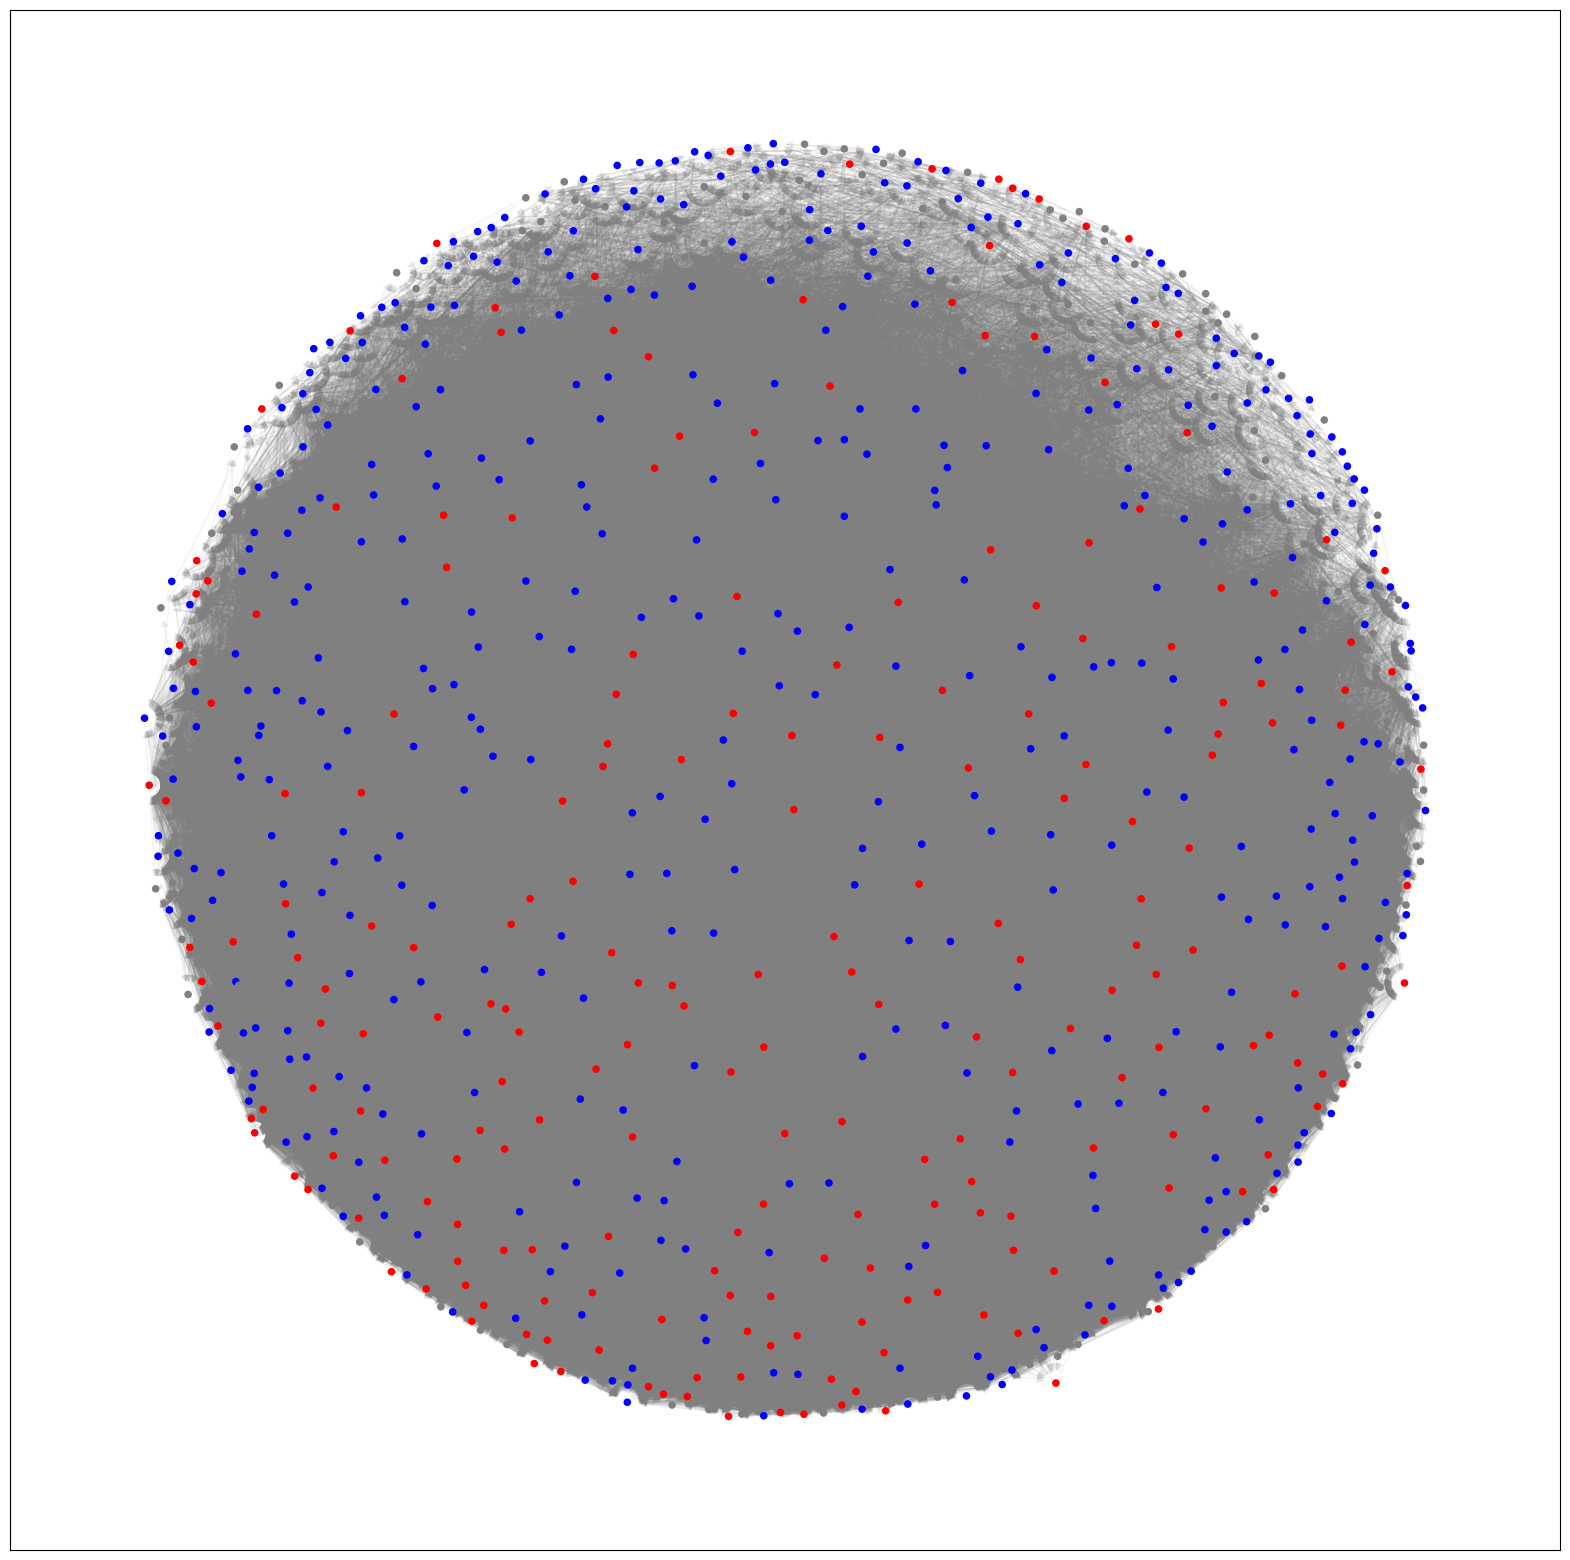

In [25]:
plt.figure(figsize=(20, 20)) 
nx.draw_networkx_edges(G, pos_arf, edge_color='gray', alpha = 0.1)
nx.draw_networkx_nodes(G, pos_arf, node_color=color_map, node_size=20)
plt.show()

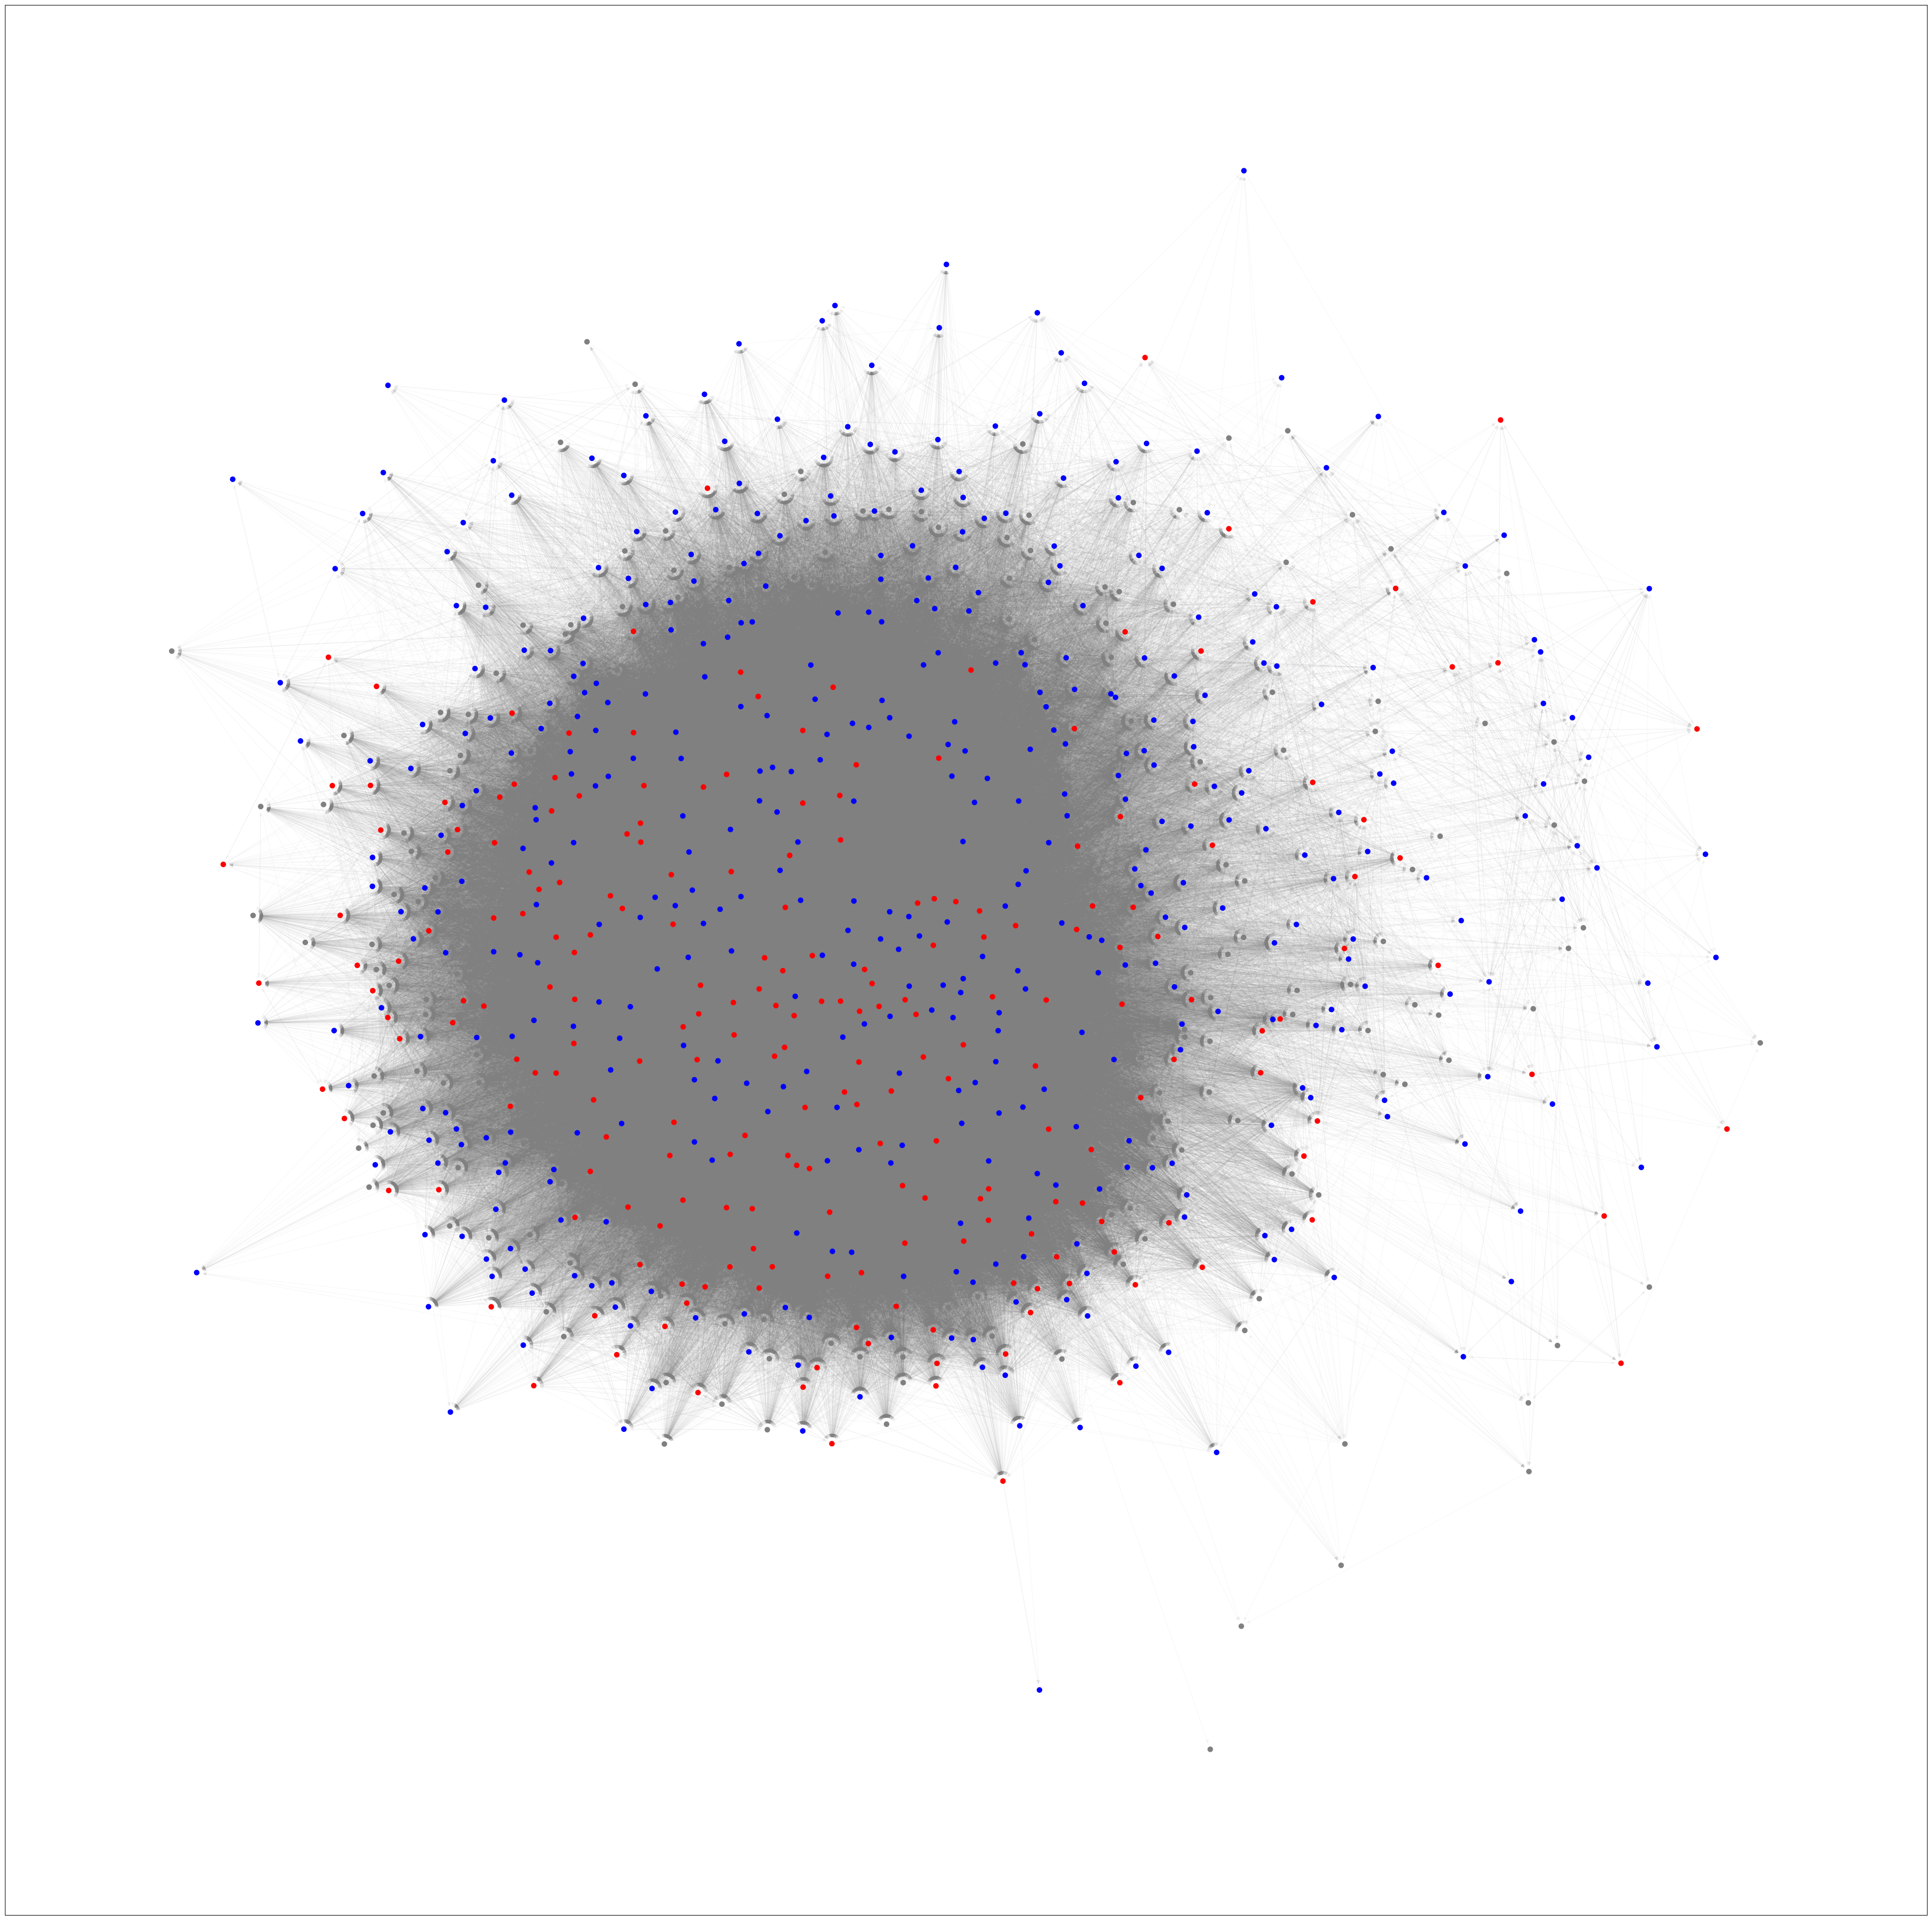

In [26]:
plt.figure(figsize=(50, 50)) 
nx.draw_networkx_edges(G, pos_kk, edge_color='gray', alpha = 0.05)
nx.draw_networkx_nodes(G, pos_kk, node_color=color_map, node_size=50)
plt.show()

Here we can see the top 5 users for degree centrality for both positive and negative sentiment scores. The degree centrality for the negative users is higher than the positive users but the sentiment scores are closer to 0 which is interesting. The negative users with the most connections aren't as negative as what might be guessed.

In [55]:
def get_top_centrality(x):
    print(df_sent.loc[df_sent['sentiment'] == 'Negative',
          ['handle','did','mean','sentiment', x]].sort_values(
              by= x, ascending = False).head(5))
    print(df_sent.loc[df_sent['sentiment'] == 'Neutral',
          ['handle','did','mean','sentiment', x]].sort_values(
              by= x, ascending = False).head(5))
    print(df_sent.loc[df_sent['sentiment'] == 'Positive',
          ['handle','did','mean','sentiment', x]].sort_values(
              by= x, ascending = False).head(5))

get_top_centrality('degree')

                          handle                               did      mean  \
235  realtuckfrumper.bsky.social  did:plc:wjatbj4hiinxfqaeixaw2bcp -0.050634   
331           drdind.bsky.social  did:plc:4p2civbp5qvabihjsxaquen2 -0.057225   
230       urocklive1.bsky.social  did:plc:ji7lroxun3yvv2pxhcf7jqsn -0.100060   
267     sykescharlie.bsky.social  did:plc:7igkthfscmolwhaexyywmzqd -0.156029   
493        drdigipol.bsky.social  did:plc:tn4ays4s4rj6noqkqoysrou3 -0.118305   

    sentiment    degree  
235  Negative  1.163163  
331  Negative  1.119119  
230  Negative  1.108108  
267  Negative  1.092092  
493  Negative  1.081081  
                       handle                               did      mean  \
21   hcrichardson.bsky.social  did:plc:wpj5z24vsmik5ocqjybwjpso -0.036064   
46   joncooper-us.bsky.social  did:plc:7qqkq2zdwq4j5jingukgtuky  0.002047   
301     patti3333.bsky.social  did:plc:dz5f3vjel76gadbwitlu7igz  0.048607   
446   sandibachom.bsky.social  did:plc:bzlqquedw2y57syi

Unsurprisingly for betweenness centrality the highest scorer is the third most followed Bluesky user Mark Hamill (aka Luke Skywalker, The Joker, Firelord Ozai just to name a few other roles), this means that since he is famous for many acting roles he is definitely likely to bridge many different subgroups within the network (despite his propensity for posting a lot of politically focus content.)

In [50]:
get_top_centrality('betweenness')

                          handle                               did      mean  \
43        bencollins.bsky.social  did:plc:x4qyokjtdzgl7gmqhsw4ajqj -0.059793   
235  realtuckfrumper.bsky.social  did:plc:wjatbj4hiinxfqaeixaw2bcp -0.050634   
280        jerilryan.bsky.social  did:plc:fgxcknpm4lhmzizgyqq73bo6 -0.076274   
267     sykescharlie.bsky.social  did:plc:7igkthfscmolwhaexyywmzqd -0.156029   
300           swin24.bsky.social  did:plc:jp6kosbeb3bkbadjr2ttznbu -0.074254   

    sentiment  betweenness  
43   Negative     0.016383  
235  Negative     0.007768  
280  Negative     0.007661  
267  Negative     0.006624  
300  Negative     0.005890  
                            handle                               did  \
2   markhamillofficial.bsky.social  did:plc:xyddpg6usmgh2t2jgf4e37yk   
21        hcrichardson.bsky.social  did:plc:wpj5z24vsmik5ocqjybwjpso   
10                     atrupar.com  did:plc:4llrhdclvdlmmynkwsmg5tdc   
0                  aoc.bsky.social  did:plc:p7gxyfr5vii5n

For closeness and eigenvector we have another unsurprising result, the highest scorers is AOC, the most followed user on Bluesky. She is very high profile and definitely has a lot of connections to other users making the connection between other nodes and connection to other high profile nodes not surprising.

In [51]:
get_top_centrality('eigenvector')

                    handle                               did      mean  \
43  bencollins.bsky.social  did:plc:x4qyokjtdzgl7gmqhsw4ajqj -0.059793   
30        acyn.bsky.social  did:plc:iu4j537hox5huj4bwnwgub4z -0.054510   
14    gtconway.bsky.social  did:plc:4lx6nur5wstwoc4wtgj56kyu -0.064359   
79  mrjoncryer.bsky.social  did:plc:dc7hahfvdre6baxdjs65icls -0.140987   
31          propublica.org  did:plc:k4jt6heuiamymgi46yeuxtpt -0.127736   

   sentiment  eigenvector  
43  Negative     0.073279  
30  Negative     0.070288  
14  Negative     0.064895  
79  Negative     0.063272  
31  Negative     0.061441  
                      handle                               did      mean  \
0            aoc.bsky.social  did:plc:p7gxyfr5vii5ntpwo7f6dhe2 -0.003449   
10               atrupar.com  did:plc:4llrhdclvdlmmynkwsmg5tdc  0.004041   
21  hcrichardson.bsky.social  did:plc:wpj5z24vsmik5ocqjybwjpso -0.036064   
32   mehdirhasan.bsky.social  did:plc:j53tav4pdcpfxyx2gcfr5fhb -0.045539   
6      

In [52]:
get_top_centrality('closeness')

                    handle                               did      mean  \
43  bencollins.bsky.social  did:plc:x4qyokjtdzgl7gmqhsw4ajqj -0.059793   
30        acyn.bsky.social  did:plc:iu4j537hox5huj4bwnwgub4z -0.054510   
4              nytimes.com  did:plc:eclio37ymobqex2ncko63h4r -0.103323   
14    gtconway.bsky.social  did:plc:4lx6nur5wstwoc4wtgj56kyu -0.064359   
31          propublica.org  did:plc:k4jt6heuiamymgi46yeuxtpt -0.127736   

   sentiment  closeness  
43  Negative   0.635444  
30  Negative   0.608235  
4   Negative   0.585978  
14  Negative   0.585588  
31  Negative   0.584811  
                            handle                               did  \
0                  aoc.bsky.social  did:plc:p7gxyfr5vii5ntpwo7f6dhe2   
10                     atrupar.com  did:plc:4llrhdclvdlmmynkwsmg5tdc   
32         mehdirhasan.bsky.social  did:plc:j53tav4pdcpfxyx2gcfr5fhb   
2   markhamillofficial.bsky.social  did:plc:xyddpg6usmgh2t2jgf4e37yk   
6               maddow.bsky.social  did

After analyzing the different sentiment categories we can see that there are a number of distinct trends within the centrality measures. After looking at the average metrics (mean and median) for all four centrality measures we can see that the users that have negative sentiment have higher values in all than those that have a positive sentiment. This is interesting considering as found before there are many more positive users and there are more users that have any only positive sentiment than those that have only a negative sentiment. Despite this the degree centrality is much higher for negative sentiment than positive meaning that negative users tend to have more connections than their positive counterparts even though there are more than double the number of positive accounts than negative ones. 

Similarly for eigenvector centrality the negative vastly outpaces the positive meaning that the negative nodes are better connected to other well connected nodes in the network. Betweenness and closeness centrality are much closer together but the negative users still slightly outpace the positive ones meaning that the negative users tend to bridge different groups and are used to connect networks more than the positive users. This means that overall the negative users in this network are better connected and have much more influence than the positive users which is likely the cause of the idea that social media has such a negative perspective on everything. Again this is half the number of the positive users but still having major impacts on the network.

In [29]:
df_sent.loc[:,['sentiment','degree','betweenness','eigenvector','closeness']].groupby('sentiment').agg(['mean', 'median', 'min', 'max']).T

sentiment           Negative   Neutral  Positive
degree      mean    0.474479  0.437846  0.355636
            median  0.450450  0.399399  0.297297
            min     0.008008  0.001001  0.003003
            max     1.163163  1.215215  1.085085
betweenness mean    0.000974  0.001067  0.000802
            median  0.000460  0.000391  0.000318
            min     0.000000  0.000000  0.000000
            max     0.016383  0.021230  0.019380
eigenvector mean    0.030684  0.028339  0.024762
            median  0.030707  0.028435  0.024687
            min     0.000151  0.000051  0.000119
            max     0.073279  0.083563  0.078808
closeness   mean    0.485370  0.481374  0.474619
            median  0.488748  0.480483  0.477099
            min     0.326436  0.284436  0.321414
            max     0.635444  0.699543  0.643805